<a href="https://colab.research.google.com/github/stephanie465337/Data-Science-Portfolio-C21/blob/main/Projects/Project-1/Project_1_data_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project 1 – To Do List



## Problem Definition

1. Write a concise problem definition for the project. Put it in a text field at the top of your Jupyter notebook.



The goal of this project is to predict whether a customer will make a future transaction based on historical transaction data. This project will use Gaussian Naive Bayes classification as the machine learning model.

## Data Collection





###Import Data


2. Load Pandas, Numpy, and Matplotlib.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn import datasets, metrics, model_selection
from sklearn import model_selection
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import train_test_split

3. Load data Train.csv from AWS S3.

In [ ]:
url = 'https://ddc-datascience.s3.amazonaws.com/Projects/Project.1-Transactions/Data/Transaction.train.big.csv'
url

'https://ddc-datascience.s3.amazonaws.com/Projects/Project.1-Transactions/Data/Transaction.train.big.csv'

In [ ]:
df = pd.read_csv(url)
df

,Unnamed: 0,ID_code,target,var_0,var_1,var_2,var_3,var_4,var_5,var_6,...,var_91,var_92,var_93,var_94,var_95,var_96,var_97,var_98,var_99,var_100
0,0,train_0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,train_1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,train_2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,train_3,0.0,4.6739,22.3915,15.6015,NaN,0.0464,NaN,NaN,...,NaN,11.1077,NaN,-12.6465,NaN,NaN,NaN,NaN,NaN,14.0618
4,4,train_4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1049995,1049995,train_1049995,1.0,11.3251,16.4148,20.5955,NaN,-6.3011,NaN,NaN,...,NaN,1.3921,NaN,-16.4925,NaN,NaN,NaN,NaN,NaN,14.4421
1049996,1049996,train_1049996,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1049997,1049997,train_1049997,0.0,8.9941,13.4127,3.9567,NaN,3.5744,NaN,NaN,...,NaN,2.0836,NaN,-18.6168,NaN,NaN,NaN,NaN,NaN,14.0689
1049998,1049998,train_1049998,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Data Cleaning

4. Examine the data using tools we have used in class.



###Make a copy

In [ ]:
df_clean = df.copy()
df_clean

,Unnamed: 0,ID_code,target,var_0,var_1,var_2,var_3,var_4,var_5,var_6,...,var_91,var_92,var_93,var_94,var_95,var_96,var_97,var_98,var_99,var_100
0,0,train_0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,train_1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,train_2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,train_3,0.0,4.6739,22.3915,15.6015,NaN,0.0464,NaN,NaN,...,NaN,11.1077,NaN,-12.6465,NaN,NaN,NaN,NaN,NaN,14.0618
4,4,train_4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1049995,1049995,train_1049995,1.0,11.3251,16.4148,20.5955,NaN,-6.3011,NaN,NaN,...,NaN,1.3921,NaN,-16.4925,NaN,NaN,NaN,NaN,NaN,14.4421
1049996,1049996,train_1049996,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1049997,1049997,train_1049997,0.0,8.9941,13.4127,3.9567,NaN,3.5744,NaN,NaN,...,NaN,2.0836,NaN,-18.6168,NaN,NaN,NaN,NaN,NaN,14.0689
1049998,1049998,train_1049998,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


###shape

In [ ]:
df_clean.shape

(1050000, 104)

###isnull()

In [ ]:
df_clean.isnull().sum()*1000

,0
Unnamed: 0,0
ID_code,0
target,870000000
var_0,870000000
var_1,870000000
...,...
var_96,1050000000
var_97,1050000000
var_98,1050000000
var_99,1050000000


In [ ]:
df_clean.isnull().sum().sort_values()

,0
Unnamed: 0,0
ID_code,0
target,870000
var_0,870000
var_1,870000
...,...
var_93,1050000
var_96,1050000
var_97,1050000
var_98,1050000


###value_counts()

In [ ]:
df_clean['target'].value_counts()

,count
target,
0.0,161960
1.0,18040


In [ ]:
#dropna = False includes how many nulls as well
df_clean['target'].value_counts(dropna = False)

,count
target,
NaN,870000
0.0,161960
1.0,18040


5. If there are data cleaning issues, develop recommendations for how to deal with them.

###dropna()

####Rows


In [ ]:
#Checks for nulls in the specified column and deletes that row.
df_clean.dropna(subset = ['target'])

,Unnamed: 0,ID_code,target,var_0,var_1,var_2,var_3,var_4,var_5,var_6,...,var_91,var_92,var_93,var_94,var_95,var_96,var_97,var_98,var_99,var_100
3,3,train_3,0.0,4.6739,22.3915,15.6015,NaN,0.0464,NaN,NaN,...,NaN,11.1077,NaN,-12.6465,NaN,NaN,NaN,NaN,NaN,14.0618
5,5,train_5,0.0,14.6962,18.3383,17.4788,NaN,-9.1355,NaN,NaN,...,NaN,-2.0111,NaN,-3.6166,NaN,NaN,NaN,NaN,NaN,14.4520
11,11,train_11,0.0,4.4949,14.4142,13.2219,NaN,4.9140,NaN,NaN,...,NaN,13.9424,NaN,-15.5776,NaN,NaN,NaN,NaN,NaN,14.1222
15,15,train_15,0.0,4.9657,16.2867,17.9579,NaN,0.6017,NaN,NaN,...,NaN,3.7943,NaN,5.6184,NaN,NaN,NaN,NaN,NaN,14.0619
19,19,train_19,0.0,9.4287,18.7822,10.7630,NaN,-0.7532,NaN,NaN,...,NaN,-5.6677,NaN,-1.8961,NaN,NaN,NaN,NaN,NaN,14.0275
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1049990,1049990,train_1049990,0.0,7.9632,20.4650,10.7295,NaN,2.9322,NaN,NaN,...,NaN,10.4219,NaN,-19.7158,NaN,NaN,NaN,NaN,NaN,14.0582
1049993,1049993,train_1049993,0.0,5.0862,14.4785,17.3709,NaN,-2.4732,NaN,NaN,...,NaN,-2.8052,NaN,-13.7290,NaN,NaN,NaN,NaN,NaN,14.3794
1049995,1049995,train_1049995,1.0,11.3251,16.4148,20.5955,NaN,-6.3011,NaN,NaN,...,NaN,1.3921,NaN,-16.4925,NaN,NaN,NaN,NaN,NaN,14.4421
1049997,1049997,train_1049997,0.0,8.9941,13.4127,3.9567,NaN,3.5744,NaN,NaN,...,NaN,2.0836,NaN,-18.6168,NaN,NaN,NaN,NaN,NaN,14.0689


In [ ]:
#Verify nothing has changed by running shape. Row count remained the same
df_clean.shape

(1050000, 104)

In [ ]:
#inplace = True changes data. Note rows at bottom right
df_clean.dropna(subset = ['target'], inplace = True)
df_clean

,Unnamed: 0,ID_code,target,var_0,var_1,var_2,var_3,var_4,var_5,var_6,...,var_91,var_92,var_93,var_94,var_95,var_96,var_97,var_98,var_99,var_100
3,3,train_3,0.0,4.6739,22.3915,15.6015,NaN,0.0464,NaN,NaN,...,NaN,11.1077,NaN,-12.6465,NaN,NaN,NaN,NaN,NaN,14.0618
5,5,train_5,0.0,14.6962,18.3383,17.4788,NaN,-9.1355,NaN,NaN,...,NaN,-2.0111,NaN,-3.6166,NaN,NaN,NaN,NaN,NaN,14.4520
11,11,train_11,0.0,4.4949,14.4142,13.2219,NaN,4.9140,NaN,NaN,...,NaN,13.9424,NaN,-15.5776,NaN,NaN,NaN,NaN,NaN,14.1222
15,15,train_15,0.0,4.9657,16.2867,17.9579,NaN,0.6017,NaN,NaN,...,NaN,3.7943,NaN,5.6184,NaN,NaN,NaN,NaN,NaN,14.0619
19,19,train_19,0.0,9.4287,18.7822,10.7630,NaN,-0.7532,NaN,NaN,...,NaN,-5.6677,NaN,-1.8961,NaN,NaN,NaN,NaN,NaN,14.0275
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1049990,1049990,train_1049990,0.0,7.9632,20.4650,10.7295,NaN,2.9322,NaN,NaN,...,NaN,10.4219,NaN,-19.7158,NaN,NaN,NaN,NaN,NaN,14.0582
1049993,1049993,train_1049993,0.0,5.0862,14.4785,17.3709,NaN,-2.4732,NaN,NaN,...,NaN,-2.8052,NaN,-13.7290,NaN,NaN,NaN,NaN,NaN,14.3794
1049995,1049995,train_1049995,1.0,11.3251,16.4148,20.5955,NaN,-6.3011,NaN,NaN,...,NaN,1.3921,NaN,-16.4925,NaN,NaN,NaN,NaN,NaN,14.4421
1049997,1049997,train_1049997,0.0,8.9941,13.4127,3.9567,NaN,3.5744,NaN,NaN,...,NaN,2.0836,NaN,-18.6168,NaN,NaN,NaN,NaN,NaN,14.0689


In [ ]:
#Run shape to verify
df_clean.shape

(180000, 104)

####Columns

In [ ]:
df_clean.columns

Index(['Unnamed: 0', 'ID_code', 'target', 'var_0', 'var_1', 'var_2', 'var_3',
       'var_4', 'var_5', 'var_6',
       ...
       'var_91', 'var_92', 'var_93', 'var_94', 'var_95', 'var_96', 'var_97',
       'var_98', 'var_99', 'var_100'],
      dtype='object', length=104)

In [ ]:
#Just to view. Watch how the columns in shape 104 change to 53 in this dropna
df_clean.dropna(axis='columns')

,Unnamed: 0,ID_code,target,var_0,var_1,var_2,var_4,var_7,var_8,var_14,...,var_83,var_84,var_85,var_86,var_87,var_88,var_89,var_92,var_94,var_100
3,3,train_3,0.0,4.6739,22.3915,15.6015,0.0464,-1.9254,6.4760,21.6435,...,11.8011,3.9677,9.5382,-8.4394,5.5043,2.2732,1.6362,11.1077,-12.6465,14.0618
5,5,train_5,0.0,14.6962,18.3383,17.4788,-9.1355,-6.4882,6.0821,11.7476,...,11.8294,3.8887,8.8591,6.1482,8.5833,2.8432,1.8434,-2.0111,-3.6166,14.4520
11,11,train_11,0.0,4.4949,14.4142,13.2219,4.9140,4.0501,5.8144,18.7136,...,11.7464,4.0017,5.8179,10.4951,12.4494,2.8009,0.3394,13.9424,-15.5776,14.1222
15,15,train_15,0.0,4.9657,16.2867,17.9579,0.6017,-5.4904,6.6670,8.1019,...,11.5481,3.9809,8.2247,21.2257,6.9931,3.3939,-2.3905,3.7943,5.6184,14.0619
19,19,train_19,0.0,9.4287,18.7822,10.7630,-0.7532,8.8477,6.8045,19.0069,...,10.8981,4.1808,9.4220,1.8563,10.5738,1.2409,-1.3888,-5.6677,-1.8961,14.0275
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1049990,1049990,train_1049990,0.0,7.9632,20.4650,10.7295,2.9322,5.0267,7.1953,10.0695,...,12.1000,4.2019,7.1249,14.6591,10.2705,3.5833,2.5588,10.4219,-19.7158,14.0582
1049993,1049993,train_1049993,0.0,5.0862,14.4785,17.3709,-2.4732,-2.5987,6.6798,3.0420,...,10.9960,3.9637,8.0217,11.0449,9.3100,1.0545,-2.8770,-2.8052,-13.7290,14.3794
1049995,1049995,train_1049995,1.0,11.3251,16.4148,20.5955,-6.3011,-6.8112,7.3226,14.9182,...,11.2265,3.8431,8.2748,-7.8464,9.9774,1.7377,-1.7942,1.3921,-16.4925,14.4421
1049997,1049997,train_1049997,0.0,8.9941,13.4127,3.9567,3.5744,1.6614,6.1486,12.0996,...,10.5067,4.0642,8.3381,17.9081,12.3357,2.6530,-1.2359,2.0836,-18.6168,14.0689


In [ ]:
#View dropped column nulls
df_clean.dropna(axis='columns', how = 'all')

,Unnamed: 0,ID_code,target,var_0,var_1,var_2,var_4,var_7,var_8,var_14,...,var_83,var_84,var_85,var_86,var_87,var_88,var_89,var_92,var_94,var_100
3,3,train_3,0.0,4.6739,22.3915,15.6015,0.0464,-1.9254,6.4760,21.6435,...,11.8011,3.9677,9.5382,-8.4394,5.5043,2.2732,1.6362,11.1077,-12.6465,14.0618
5,5,train_5,0.0,14.6962,18.3383,17.4788,-9.1355,-6.4882,6.0821,11.7476,...,11.8294,3.8887,8.8591,6.1482,8.5833,2.8432,1.8434,-2.0111,-3.6166,14.4520
11,11,train_11,0.0,4.4949,14.4142,13.2219,4.9140,4.0501,5.8144,18.7136,...,11.7464,4.0017,5.8179,10.4951,12.4494,2.8009,0.3394,13.9424,-15.5776,14.1222
15,15,train_15,0.0,4.9657,16.2867,17.9579,0.6017,-5.4904,6.6670,8.1019,...,11.5481,3.9809,8.2247,21.2257,6.9931,3.3939,-2.3905,3.7943,5.6184,14.0619
19,19,train_19,0.0,9.4287,18.7822,10.7630,-0.7532,8.8477,6.8045,19.0069,...,10.8981,4.1808,9.4220,1.8563,10.5738,1.2409,-1.3888,-5.6677,-1.8961,14.0275
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1049990,1049990,train_1049990,0.0,7.9632,20.4650,10.7295,2.9322,5.0267,7.1953,10.0695,...,12.1000,4.2019,7.1249,14.6591,10.2705,3.5833,2.5588,10.4219,-19.7158,14.0582
1049993,1049993,train_1049993,0.0,5.0862,14.4785,17.3709,-2.4732,-2.5987,6.6798,3.0420,...,10.9960,3.9637,8.0217,11.0449,9.3100,1.0545,-2.8770,-2.8052,-13.7290,14.3794
1049995,1049995,train_1049995,1.0,11.3251,16.4148,20.5955,-6.3011,-6.8112,7.3226,14.9182,...,11.2265,3.8431,8.2748,-7.8464,9.9774,1.7377,-1.7942,1.3921,-16.4925,14.4421
1049997,1049997,train_1049997,0.0,8.9941,13.4127,3.9567,3.5744,1.6614,6.1486,12.0996,...,10.5067,4.0642,8.3381,17.9081,12.3357,2.6530,-1.2359,2.0836,-18.6168,14.0689


In [ ]:
#Make actual change
df_clean.dropna(axis='columns', how = 'all', inplace = True)

In [ ]:
#Verify rows and columns
df_clean.shape

(180000, 53)

In [ ]:
df_clean.isnull().sum().sum()

np.int64(0)

In [ ]:
df_backup = df_clean.copy()

## Exploratory Data Analysis








6. Produce some visual analysis of the data – like plots showing the distributions of all variables. Recall that Gaussian Naive Bayes assumes the predictors are normally distributed. Note: you might have to do multiple plots in groups.


###hist()

In [ ]:
df_backup.shape

(180000, 53)

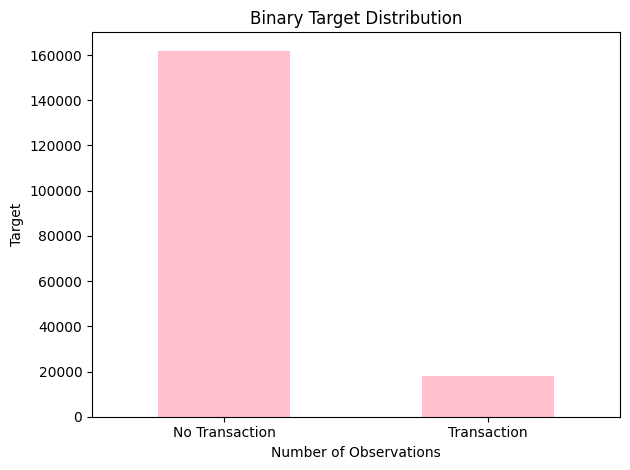

In [ ]:
#value_counts() counts how many times each value appears.
df_backup['target'].value_counts().rename(index={
    0: 'No Transaction',
    1: 'Transaction'
}).plot(kind='bar', color='pink')

plt.title("Binary Target Distribution")
plt.xlabel('Number of Observations')
plt.ylabel('Target')
plt.xticks(rotation=0)  #Makes labels horizontal

plt.tight_layout()
plt.savefig('Binary Target.png')
plt.show()

In [ ]:
df_backup.columns

Index(['Unnamed: 0', 'ID_code', 'target', 'var_0', 'var_1', 'var_2', 'var_4',
       'var_7', 'var_8', 'var_14', 'var_15', 'var_17', 'var_20', 'var_21',
       'var_22', 'var_24', 'var_26', 'var_27', 'var_28', 'var_29', 'var_36',
       'var_37', 'var_38', 'var_39', 'var_41', 'var_48', 'var_49', 'var_52',
       'var_56', 'var_57', 'var_61', 'var_62', 'var_63', 'var_65', 'var_66',
       'var_67', 'var_70', 'var_72', 'var_73', 'var_75', 'var_78', 'var_80',
       'var_82', 'var_83', 'var_84', 'var_85', 'var_86', 'var_87', 'var_88',
       'var_89', 'var_92', 'var_94', 'var_100'],
      dtype='object')

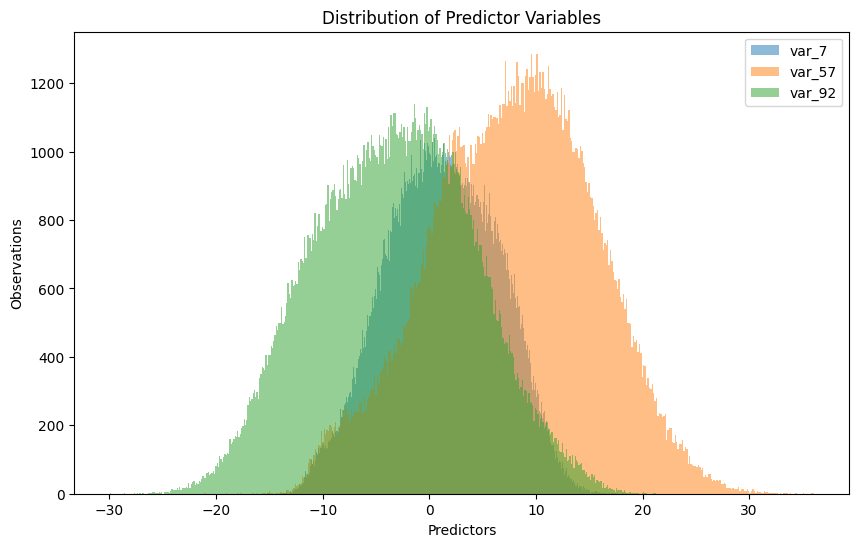

In [ ]:
#bin
n = int(180_000**(1/2))

plt.figure(figsize=(10,6))


plt.hist(df_backup['var_7'], alpha=0.5, bins=n, label='var_7')
plt.hist(df_backup['var_57'], alpha=0.5, bins=n, label='var_57')
plt.hist(df_backup['var_92'], alpha=0.5, bins=n, label='var_92')

plt.legend()
plt.title("Distribution of Predictor Variables")
plt.xlabel("Predictors")
plt.ylabel("Observations")

plt.savefig('Predictor Vars.png')
plt.show()

In [ ]:
!ls

'Binary Target.png'  'Correlation Matrix.png'  'Predictor Vars.svg'
'Binary Target.svg'  'Predictor Vars.png'       sample_data


7. NOTE: the ‘target’ column indicates a successful transaction (‘1’) or a no-transaction (‘0’). Verify these are the only values in that column.



In [ ]:
df_backup['target'].value_counts(dropna = False)

,count
target,
0.0,161960
1.0,18040


In [ ]:
# df_clean.drop(columns=['Unnamed: 0', 'target'], inplace=True)
# df_clean

8. Check the correlation values between all **predictor columns** to ensure there are no substantial correlations between predictors. This is important to support the decision to classify the ‘target’ using Naïve Bayes.



###corr()

In [ ]:
import seaborn as sns

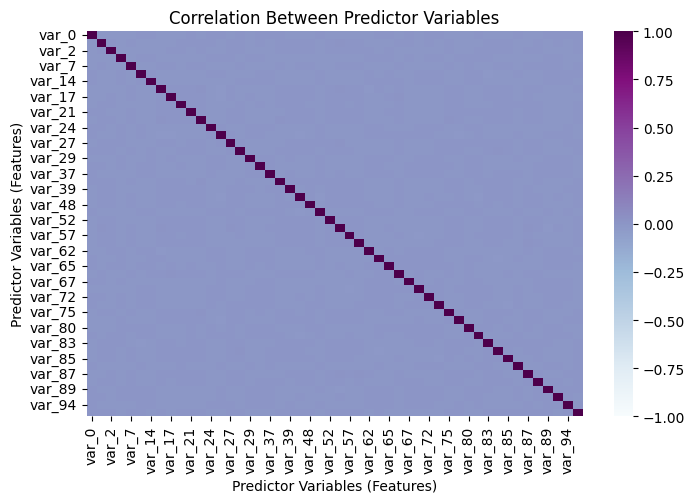

In [ ]:
#Should always have a diagonal of 1.0
corr = df_backup.drop(columns=['Unnamed: 0', 'ID_code', 'target']).corr() #Actual correlation matrix

plt.figure(figsize=(8, 5))

#annot prints the actual numbers inside each box
sns.heatmap(corr, cmap='BuPu', vmin=-1, vmax=1)
plt.title('Correlation Between Predictor Variables')
plt.xlabel('Predictor Variables (Features)')
plt.ylabel('Predictor Variables (Features)')

plt.savefig('Correlation Matrix.png')
plt.show()

In [ ]:
df_clean.shape

(180000, 53)

9. Create two data frames: one with all successful transactions, one with all unsuccessful transactions. **Make sure they are copies and not slices**.

In [ ]:
successful = df_backup[df_backup['target'] == 1].copy()
successful

,Unnamed: 0,ID_code,target,var_0,var_1,var_2,var_4,var_7,var_8,var_14,...,var_83,var_84,var_85,var_86,var_87,var_88,var_89,var_92,var_94,var_100
57,57,train_57,1.0,8.9078,12.1321,9.4707,-5.8102,0.4521,7.1264,15.6935,...,11.2059,4.0237,5.8905,12.4865,10.1419,2.3370,-3.1553,-12.6928,-3.0833,14.1895
125,125,train_125,1.0,6.2143,20.0990,23.5009,-0.8917,-3.9167,6.6863,21.4162,...,10.8110,3.9190,7.4971,35.7428,9.6149,2.2257,-0.5949,-9.4101,-15.6555,14.4514
151,151,train_151,1.0,8.9083,12.1117,18.0359,-4.9628,10.1135,6.8962,11.4553,...,11.6326,3.9193,5.0366,37.1453,17.0341,0.9987,-3.0163,-1.5409,-7.6389,14.1725
155,155,train_155,1.0,6.5612,13.9638,5.1980,12.1092,8.4874,6.4781,16.9541,...,11.2981,4.1316,7.2193,-1.8139,1.8190,2.5720,0.6780,6.4045,1.1754,14.1347
302,302,train_302,1.0,4.4616,9.7572,12.9317,7.6485,0.6382,5.8025,22.4577,...,11.5449,4.0001,9.0639,11.8805,9.4678,1.0561,-0.2107,9.8815,-2.9328,14.0933
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1049783,1049783,train_1049783,1.0,3.1286,15.0751,21.3962,11.3161,-10.0493,6.3525,25.4931,...,10.9172,4.1120,4.6540,9.1151,7.8918,2.5714,1.0304,5.2623,-0.6030,14.1993
1049818,1049818,train_1049818,1.0,15.2934,17.5721,5.8949,-4.0233,5.8840,7.3892,11.3932,...,11.1665,3.9652,7.4879,-7.9060,10.7256,0.8941,-3.5967,6.3976,0.5778,14.5067
1049978,1049978,train_1049978,1.0,7.4751,17.0314,5.0834,-1.5220,-2.4913,6.7953,10.7764,...,11.6605,3.6716,8.5965,19.2145,8.2747,4.0945,-3.0127,2.9477,-2.3696,14.4122
1049983,1049983,train_1049983,1.0,5.2746,14.4095,17.7709,-2.9855,-0.8515,6.5097,11.5599,...,11.8870,3.7776,6.9876,3.3482,9.7469,-0.3425,-2.5684,14.5286,-5.4146,14.4388


In [ ]:
unsuccessful = df_backup[df_backup['target'] == 0].copy()
unsuccessful

,Unnamed: 0,ID_code,target,var_0,var_1,var_2,var_4,var_7,var_8,var_14,...,var_83,var_84,var_85,var_86,var_87,var_88,var_89,var_92,var_94,var_100
3,3,train_3,0.0,4.6739,22.3915,15.6015,0.0464,-1.9254,6.4760,21.6435,...,11.8011,3.9677,9.5382,-8.4394,5.5043,2.2732,1.6362,11.1077,-12.6465,14.0618
5,5,train_5,0.0,14.6962,18.3383,17.4788,-9.1355,-6.4882,6.0821,11.7476,...,11.8294,3.8887,8.8591,6.1482,8.5833,2.8432,1.8434,-2.0111,-3.6166,14.4520
11,11,train_11,0.0,4.4949,14.4142,13.2219,4.9140,4.0501,5.8144,18.7136,...,11.7464,4.0017,5.8179,10.4951,12.4494,2.8009,0.3394,13.9424,-15.5776,14.1222
15,15,train_15,0.0,4.9657,16.2867,17.9579,0.6017,-5.4904,6.6670,8.1019,...,11.5481,3.9809,8.2247,21.2257,6.9931,3.3939,-2.3905,3.7943,5.6184,14.0619
19,19,train_19,0.0,9.4287,18.7822,10.7630,-0.7532,8.8477,6.8045,19.0069,...,10.8981,4.1808,9.4220,1.8563,10.5738,1.2409,-1.3888,-5.6677,-1.8961,14.0275
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1049988,1049988,train_1049988,0.0,10.7453,13.3217,15.4001,4.0421,1.3116,6.3990,13.9387,...,11.6062,3.9162,9.7054,15.2405,10.6480,0.5372,0.4014,4.8258,-8.2380,14.0328
1049990,1049990,train_1049990,0.0,7.9632,20.4650,10.7295,2.9322,5.0267,7.1953,10.0695,...,12.1000,4.2019,7.1249,14.6591,10.2705,3.5833,2.5588,10.4219,-19.7158,14.0582
1049993,1049993,train_1049993,0.0,5.0862,14.4785,17.3709,-2.4732,-2.5987,6.6798,3.0420,...,10.9960,3.9637,8.0217,11.0449,9.3100,1.0545,-2.8770,-2.8052,-13.7290,14.3794
1049997,1049997,train_1049997,0.0,8.9941,13.4127,3.9567,3.5744,1.6614,6.1486,12.0996,...,10.5067,4.0642,8.3381,17.9081,12.3357,2.6530,-1.2359,2.0836,-18.6168,14.0689


## Data Processing





10. Create two data frames: one with all the predictor columns (everything except for Unnamed: 0, ID_code and target) and one with just the target. Make sure they are copies and not slices.



In [ ]:
X = df_backup.drop(columns=['Unnamed: 0', 'ID_code', 'target']).copy()
X

,var_0,var_1,var_2,var_4,var_7,var_8,var_14,var_15,var_17,var_20,...,var_83,var_84,var_85,var_86,var_87,var_88,var_89,var_92,var_94,var_100
3,4.6739,22.3915,15.6015,0.0464,-1.9254,6.4760,21.6435,2.8817,11.6975,0.5878,...,11.8011,3.9677,9.5382,-8.4394,5.5043,2.2732,1.6362,11.1077,-12.6465,14.0618
5,14.6962,18.3383,17.4788,-9.1355,-6.4882,6.0821,11.7476,2.2225,7.2218,6.5456,...,11.8294,3.8887,8.8591,6.1482,8.5833,2.8432,1.8434,-2.0111,-3.6166,14.4520
11,4.4949,14.4142,13.2219,4.9140,4.0501,5.8144,18.7136,3.4990,4.2892,18.7893,...,11.7464,4.0017,5.8179,10.4951,12.4494,2.8009,0.3394,13.9424,-15.5776,14.1222
15,4.9657,16.2867,17.9579,0.6017,-5.4904,6.6670,8.1019,2.8910,8.2374,1.1400,...,11.5481,3.9809,8.2247,21.2257,6.9931,3.3939,-2.3905,3.7943,5.6184,14.0619
19,9.4287,18.7822,10.7630,-0.7532,8.8477,6.8045,19.0069,3.2771,12.6446,7.8002,...,10.8981,4.1808,9.4220,1.8563,10.5738,1.2409,-1.3888,-5.6677,-1.8961,14.0275
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1049990,7.9632,20.4650,10.7295,2.9322,5.0267,7.1953,10.0695,3.0732,11.0135,3.1549,...,12.1000,4.2019,7.1249,14.6591,10.2705,3.5833,2.5588,10.4219,-19.7158,14.0582
1049993,5.0862,14.4785,17.3709,-2.4732,-2.5987,6.6798,3.0420,2.4057,18.2729,3.9661,...,10.9960,3.9637,8.0217,11.0449,9.3100,1.0545,-2.8770,-2.8052,-13.7290,14.3794
1049995,11.3251,16.4148,20.5955,-6.3011,-6.8112,7.3226,14.9182,2.4579,14.7175,3.8858,...,11.2265,3.8431,8.2748,-7.8464,9.9774,1.7377,-1.7942,1.3921,-16.4925,14.4421
1049997,8.9941,13.4127,3.9567,3.5744,1.6614,6.1486,12.0996,2.5439,10.2936,2.0014,...,10.5067,4.0642,8.3381,17.9081,12.3357,2.6530,-1.2359,2.0836,-18.6168,14.0689


In [ ]:
y = df_backup['target'].copy()
y

,target
3,0.0
5,0.0
11,0.0
15,0.0
19,0.0
...,...
1049990,0.0
1049993,0.0
1049995,1.0
1049997,0.0


11. Define a Gaussian Naïve Bayes model using Sklearn.



In [ ]:
from sklearn.naive_bayes import GaussianNB

model = GaussianNB()

12. Divide the two data frames you created in step #10 into training and testing subsets.



In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=0)
[ _.shape for _ in [X_train, X_test, y_train, y_test] ]

[(144000, 50), (36000, 50), (144000, 1), (36000, 1)]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42 #Means the same split every time
)

13. Train the model using the training subset of the dataset.



In [ ]:
model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


GaussianNB()

14. Test the model using the testing subset of the dataset. Calculate and report the accuracy.



In [ ]:
predictors = model.predict(X_test)
predictors

array([0., 0., 0., ..., 0., 1., 0.])

In [ ]:
from sklearn.metrics import accuracy_score

In [ ]:
accuracy = accuracy_score(y_test, predictors)

print("Accuracy:", accuracy)

Accuracy: 0.9104


###Cross Validation (CV)

15. Perform a cross-validation loop to calculate the accuracy of your model. Report that accuracy. How does it compare to the accuracy you calculated in #14?



In [ ]:
from sklearn.model_selection import cross_val_score

In [ ]:
n = 100
results = np.zeros(n)

for i in range(n):

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.25,
        stratify=y
    )

    model = GaussianNB()
    model.fit(X_train, y_train)

    predictors = model.predict(X_test)

    results[i] = metrics.accuracy_score(y_test, predictors)

print(results.mean())

0.9112133333333334


###CV Histogram

16. Plot a histogram of the accuracy scores you generated in your cross-validation loop. What do you notice about the distribution of accuracy scores?



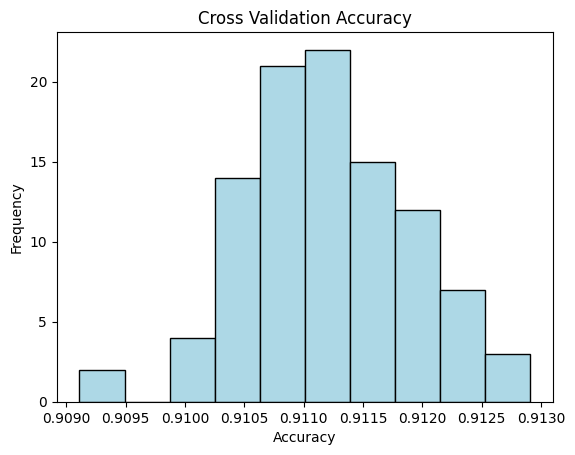

In [ ]:
plt.hist(results, bins=10, color='lightblue', edgecolor='black')
plt.title('Cross Validation Accuracy')
plt.xlabel("Accuracy")
plt.ylabel("Frequency")

plt.savefig('CV.png')
plt.show()

17.  Present the confusion matrix and the results of your Classification Report (sklearn.metrics.classification_report). What do you notice?



18. The training data is very skewed towards non-successful transactions (about 90% of the training data has ‘target’==0). Remove enough non-successful transaction rows so that your remaining training data is 50%/50% split between successful and non-successful transactions. Hint: you can use the data frames you created in step #9.



19. Repeat the cross-validation process on this data set. Report what your cross-validation accuracy is in this 50/50 case.

## Data Visualization


20. Compare the results of your cross-validation with the whole training data and the reduced 50/50 training data

1. Present the confusion matrix and the results of your Classification Report (sklearn.metrics.classification_report)




## Communicate the Results

22. Communicate the results of your analysis.



## Submit Final Project

23. Upload your finished Jupyter notebook to your Project 1 student folder.
